In [1]:
import os

# ✅ This fixes all path issues in VS Code
BASE   = r"C:\Users\ASUS\Desktop\Mutual Fund Analytics"
CHARTS = os.path.join(BASE, 'reports', 'charts')

os.makedirs(CHARTS, exist_ok=True)

print("✅ Base path set:", BASE)
print("✅ Charts folder:", CHARTS)
print("✅ Processed files available:")
for f in os.listdir(os.path.join(BASE, 'data', 'processed')):
    print("   ", f)

✅ Base path set: C:\Users\ASUS\Desktop\Mutual Fund Analytics
✅ Charts folder: C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts
✅ Processed files available:
    aum_by_fund_house_clean.csv
    benchmark_indices_clean.csv
    category_inflows_clean.csv
    fund_master_clean.csv
    industry_folio_count_clean.csv
    investor_transactions_clean.csv
    monthly_sip_inflows_clean.csv
    nav_history_clean.csv
    portfolio_holdings_clean.csv
    scheme_performance_clean.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries loaded")

✅ All libraries loaded


In [3]:
# Full absolute paths — no errors in VS Code
nav      = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'nav_history_clean.csv'),
                       parse_dates=['date'])

fund_master = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'fund_master_clean.csv'),
                          parse_dates=['launch_date'])

txn      = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'investor_transactions_clean.csv'),
                       parse_dates=['transaction_date'])

perf     = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'scheme_performance_clean.csv'))

aum      = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'aum_by_fund_house_clean.csv'),
                       parse_dates=['date'])

sip      = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'monthly_sip_inflows_clean.csv'))

cat      = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'category_inflows_clean.csv'))

folio    = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'industry_folio_count_clean.csv'))

holdings = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'portfolio_holdings_clean.csv'),
                       parse_dates=['portfolio_date'])

benchmark = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'benchmark_indices_clean.csv'),
                        parse_dates=['date'])

print("✅ All files loaded successfully!")
print(f"  NAV rows          : {len(nav):,}")
print(f"  Transactions      : {len(txn):,}")
print(f"  Fund Master       : {len(fund_master):,}")
print(f"  Performance       : {len(perf):,}")
print(f"  AUM               : {len(aum):,}")
print(f"  SIP Inflows       : {len(sip):,}")
print(f"  Category Inflows  : {len(cat):,}")
print(f"  Folio Count       : {len(folio):,}")
print(f"  Portfolio Holdings: {len(holdings):,}")
print(f"  Benchmark         : {len(benchmark):,}")

✅ All files loaded successfully!
  NAV rows          : 46,000
  Transactions      : 32,778
  Fund Master       : 40
  Performance       : 40
  AUM               : 90
  SIP Inflows       : 48
  Category Inflows  : 144
  Folio Count       : 21
  Portfolio Holdings: 322
  Benchmark         : 8,050


In [4]:
# Merge nav with scheme names
nav_named = nav.merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']],
    on='amfi_code', how='left'
)

# Filter 2022–2026
nav_named = nav_named[
    (nav_named['date'] >= '2022-01-01') &
    (nav_named['date'] <= '2026-12-31')
]

fig = px.line(
    nav_named,
    x='date', y='nav',
    color='scheme_name',
    title='Daily NAV Trend — All Schemes (2022–2026)',
    labels={
        'nav': 'NAV (₹)',
        'date': 'Date',
        'scheme_name': 'Scheme'
    }
)

# Highlight 2023 bull run
fig.add_vrect(
    x0='2023-01-01', x1='2023-12-31',
    fillcolor='green', opacity=0.08,
    annotation_text='2023 Bull Run',
    annotation_position='top left'
)

# Highlight 2024 correction
fig.add_vrect(
    x0='2024-01-01', x1='2024-06-30',
    fillcolor='red', opacity=0.08,
    annotation_text='2024 Correction',
    annotation_position='top left'
)

fig.update_layout(height=550, legend=dict(font=dict(size=9)))

# ✅ Save using BASE path
fig.write_image(os.path.join(CHARTS, 'chart1_nav_trend.png'))
fig.show()
print("✅ Chart 1 saved →", os.path.join(CHARTS, 'chart1_nav_trend.png'))

✅ Chart 1 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart1_nav_trend.png


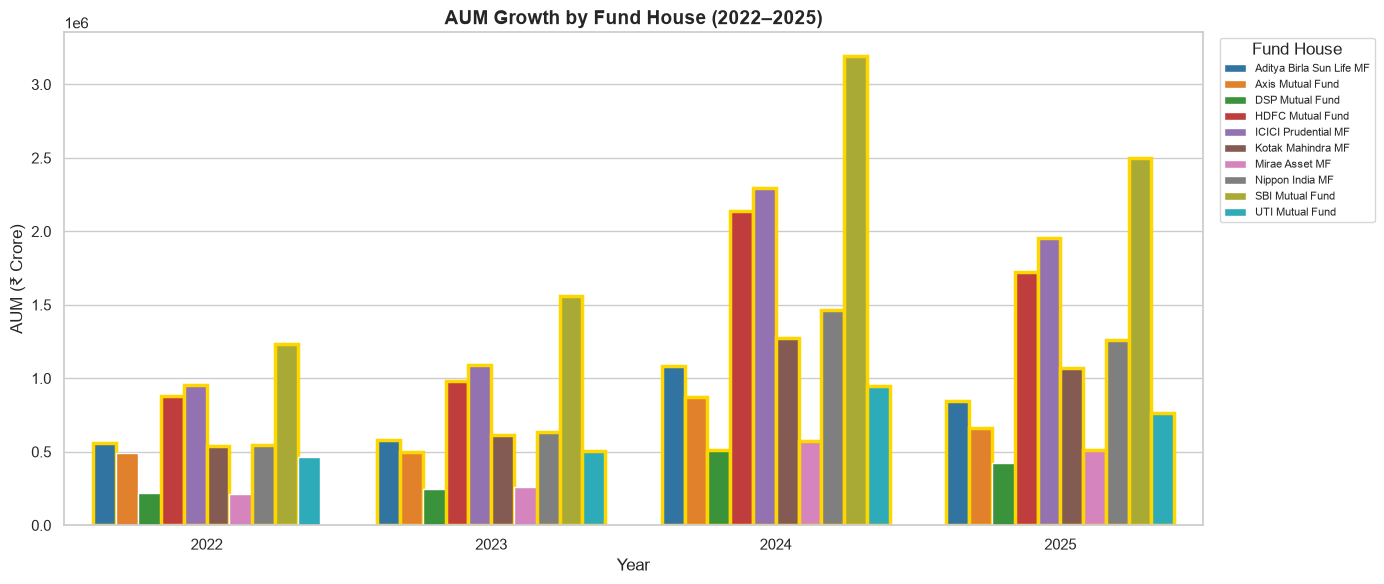

✅ Chart 2 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart2_aum_growth.png


In [5]:
aum['year'] = aum['date'].dt.year
aum_yearly  = aum.groupby(['year', 'fund_house'])['aum_crore'].sum().reset_index()

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=aum_yearly,
    x='year', y='aum_crore',
    hue='fund_house',
    palette='tab10'
)

# Highlight dominant bars
for bar in ax.patches:
    if bar.get_height() > 500000:
        bar.set_edgecolor('gold')
        bar.set_linewidth(2.5)

plt.title('AUM Growth by Fund House (2022–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('AUM (₹ Crore)')
plt.legend(title='Fund House', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()

# ✅ Save using BASE path
plt.savefig(os.path.join(CHARTS, 'chart2_aum_growth.png'), dpi=150)
plt.show()
print("✅ Chart 2 saved →", os.path.join(CHARTS, 'chart2_aum_growth.png'))

In [7]:
import os
import pandas as pd
import plotly.express as px

# Convert month column to datetime
sip['month_dt'] = pd.to_datetime(sip['month'], format='%Y-%m')

# Create line chart
fig = px.line(
    sip,
    x='month_dt',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)',
    labels={
        'month_dt': 'Month',
        'sip_inflow_crore': 'SIP Inflow (₹ Crore)'
    },
    markers=True
)

# Find all-time high
peak_row = sip.loc[sip['sip_inflow_crore'].idxmax()]

# Add annotation
fig.add_annotation(
    x=peak_row['month_dt'].to_pydatetime(),   # Convert Timestamp to Python datetime
    y=float(peak_row['sip_inflow_crore']),    # Convert to float
    text=f"₹{peak_row['sip_inflow_crore']:,.0f} Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    bgcolor="orange",
    bordercolor="black",
    borderwidth=1,
    font=dict(size=11, color="black")
)

# Improve layout
fig.update_layout(
    height=450,
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

# Save chart
output_path = os.path.join(CHARTS, "chart3_sip_trend.png")
fig.write_image(output_path, width=1200, height=600, scale=2)

# Show chart
fig.show()

print(f"✅ Chart saved → {output_path}")

✅ Chart saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart3_sip_trend.png


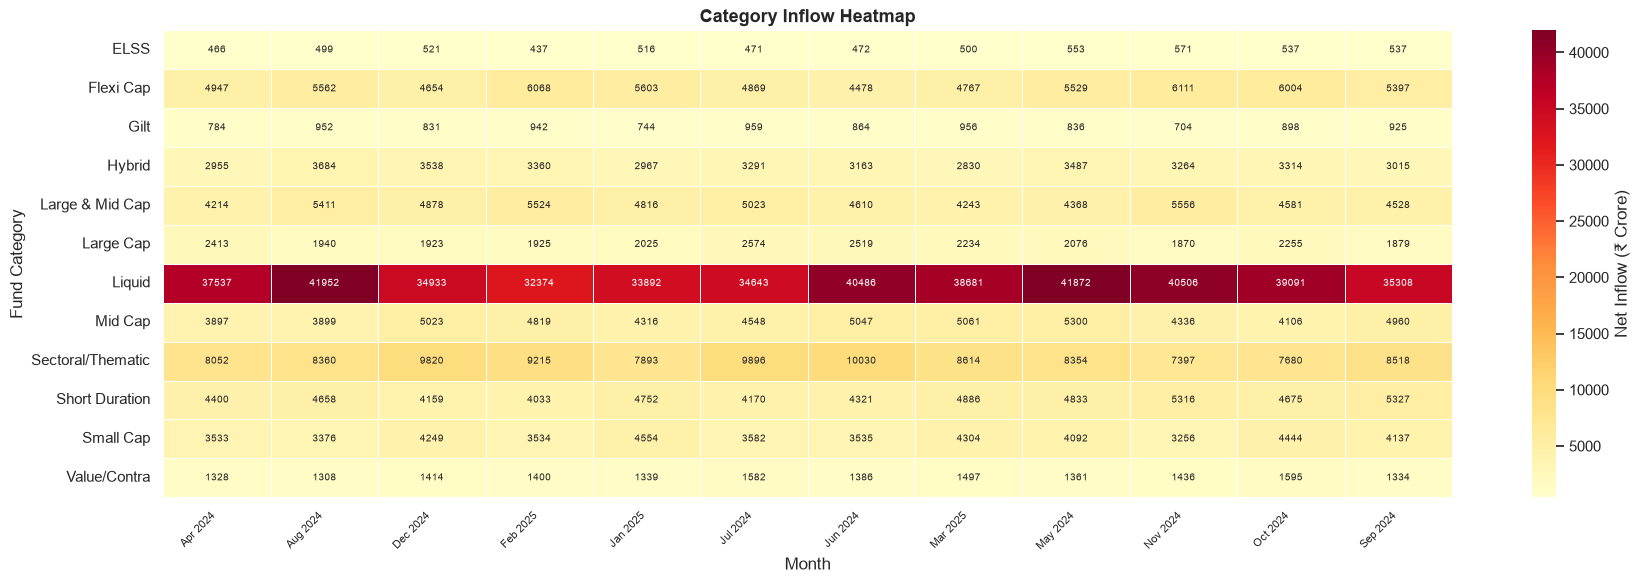

✅ Chart 4 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart4_category_heatmap.png


In [8]:
cat['month_dt']    = pd.to_datetime(cat['month'], format='%Y-%m')
cat['month_label'] = cat['month_dt'].dt.strftime('%b %Y')

pivot = cat.pivot_table(
    index='category',
    columns='month_label',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(18, 6))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    linewidths=0.4,
    annot=True, fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)
plt.title('Category Inflow Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()

# ✅ Save using BASE path
plt.savefig(os.path.join(CHARTS, 'chart4_category_heatmap.png'), dpi=150)
plt.show()
print("✅ Chart 4 saved →", os.path.join(CHARTS, 'chart4_category_heatmap.png'))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5292\124307451.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


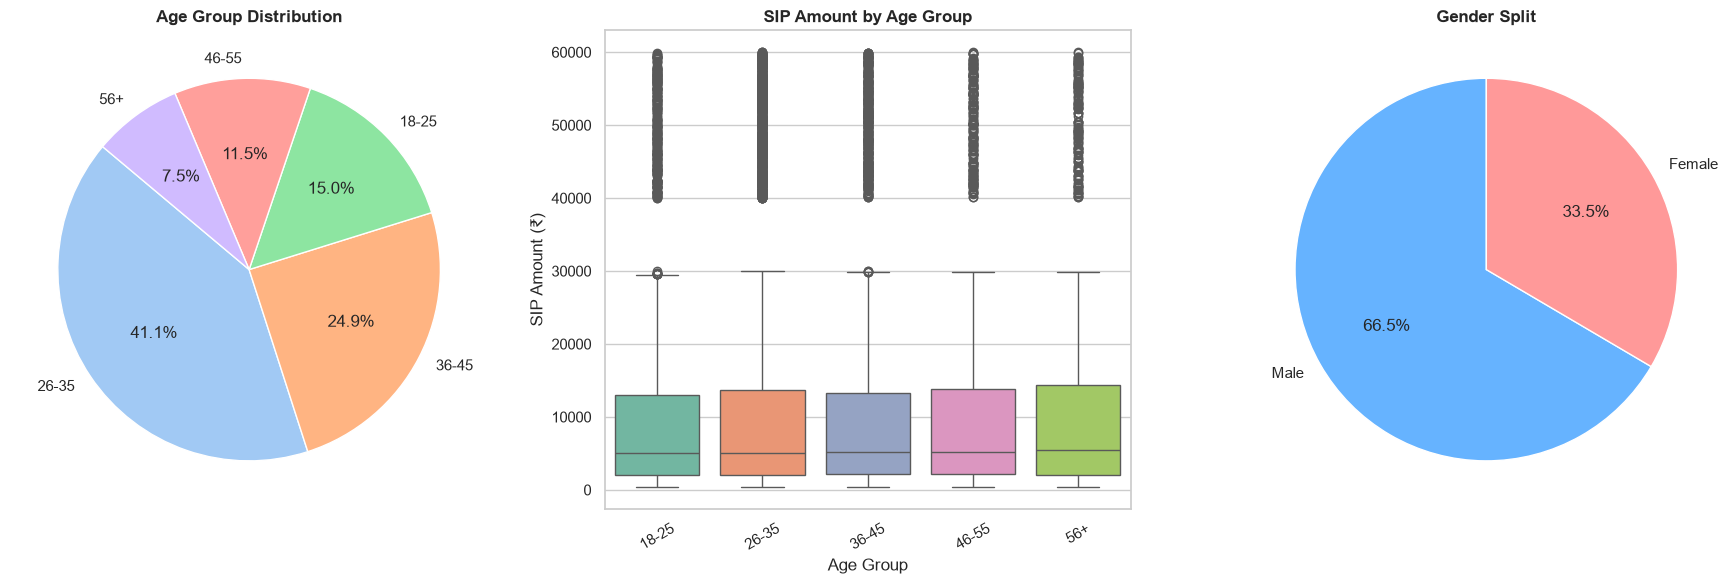

✅ Chart 5 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart5_investor_demographics.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A) Age group pie
age_counts = txn['age_group'].value_counts()
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
axes[0].set_title('Age Group Distribution', fontweight='bold')

# B) SIP amount box plot by age group
sip_txn   = txn[txn['transaction_type'] == 'SIP']
age_order = sorted(txn['age_group'].dropna().unique())
sns.boxplot(
    data=sip_txn,
    x='age_group', y='amount_inr',
    order=age_order,
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('SIP Amount by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].tick_params(axis='x', rotation=30)

# C) Gender split pie
gender_counts = txn['gender'].value_counts()
axes[2].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999', '#99ff99']
)
axes[2].set_title('Gender Split', fontweight='bold')

plt.tight_layout()

# ✅ Save using BASE path
plt.savefig(os.path.join(CHARTS, 'chart5_investor_demographics.png'), dpi=150)
plt.show()
print("✅ Chart 5 saved →", os.path.join(CHARTS, 'chart5_investor_demographics.png'))

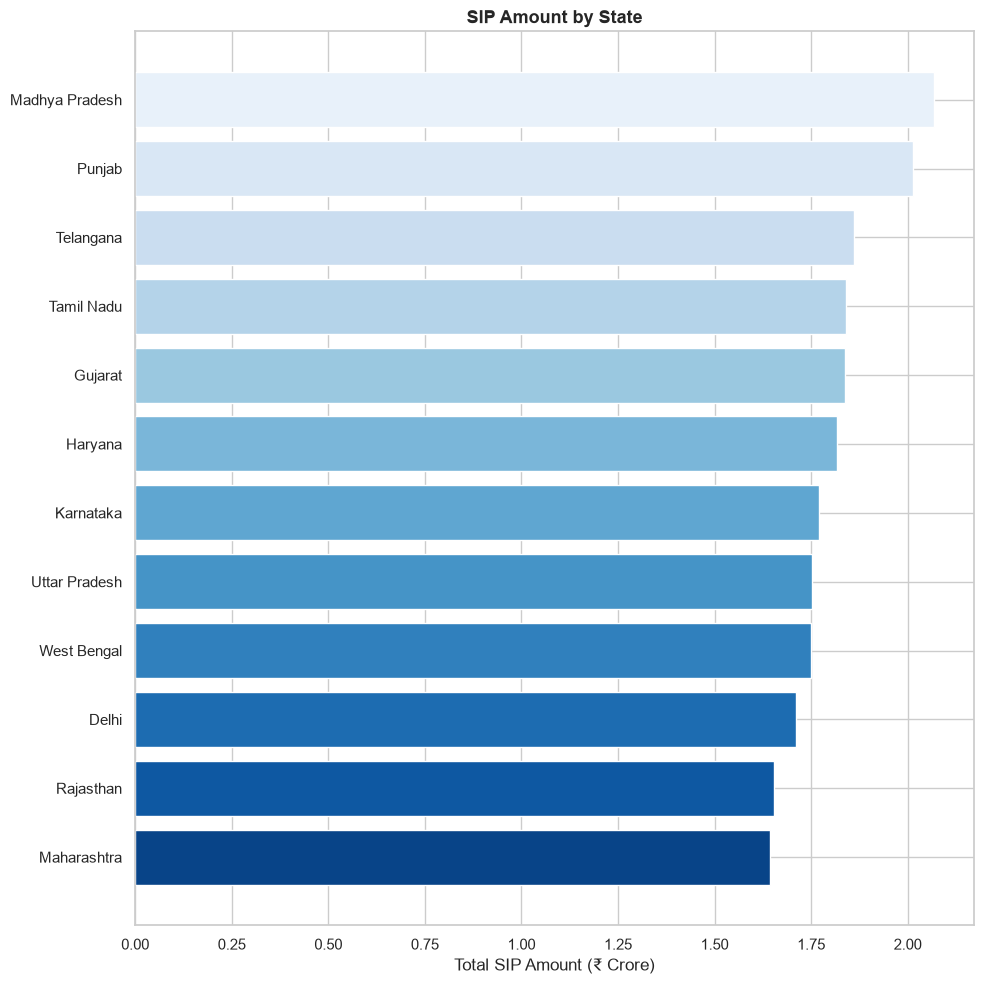

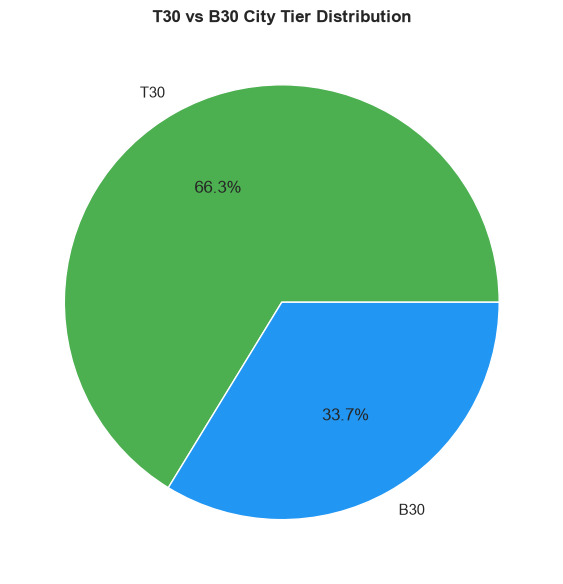

✅ Chart 6 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts


In [10]:
# A) SIP by state — horizontal bar
state_sip = (
    txn[txn['transaction_type'] == 'SIP']
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

plt.figure(figsize=(10, 10))
plt.barh(
    state_sip['state'],
    state_sip['amount_inr'] / 1e7,
    color=sns.color_palette('Blues_r', len(state_sip))
)
plt.xlabel('Total SIP Amount (₹ Crore)')
plt.title('SIP Amount by State', fontsize=13, fontweight='bold')
plt.tight_layout()

# ✅ Save using BASE path
plt.savefig(os.path.join(CHARTS, 'chart6_geographic_sip.png'), dpi=150)
plt.show()

# B) T30 vs B30 city tier pie
tier_counts = txn['city_tier'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#2196F3', '#FF9800']
)
plt.title('T30 vs B30 City Tier Distribution', fontweight='bold')
plt.tight_layout()

# ✅ Save using BASE path
plt.savefig(os.path.join(CHARTS, 'chart6b_city_tier.png'), dpi=150)
plt.show()
print("✅ Chart 6 saved →", CHARTS)

In [12]:
import os
import pandas as pd
import plotly.graph_objects as go

# Convert month column to datetime
folio['month_dt'] = pd.to_datetime(folio['month'], format='%Y-%m')

# Create figure
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=folio['month_dt'],
        y=folio['total_folios_crore'],
        mode='lines+markers',
        name='Total Folios',
        line=dict(color='royalblue', width=2.5),
        marker=dict(size=6)
    )
)

# Find peak row
peak_row = folio.loc[folio['total_folios_crore'].idxmax()]

# Add annotation (FIXED)
fig.add_annotation(
    x=peak_row['month_dt'].to_pydatetime(),   # Convert Timestamp
    y=float(peak_row['total_folios_crore']),  # Convert to float
    text=f"Peak: {peak_row['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    bgcolor='lightgreen',
    bordercolor='black',
    borderwidth=1,
    font=dict(size=11, color='black')
)

# Update layout
fig.update_layout(
    title='Folio Count Growth (Jan 2022 → Dec 2025)',
    xaxis_title='Month',
    yaxis_title='Total Folios (Crore)',
    height=430,
    template='plotly_white'
)

# Save chart
output_path = os.path.join(CHARTS, 'chart7_folio_growth.png')
fig.write_image(output_path, width=1200, height=600, scale=2)

# Display chart
fig.show()

print(f"✅ Chart 7 saved → {output_path}")

✅ Chart 7 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart7_folio_growth.png


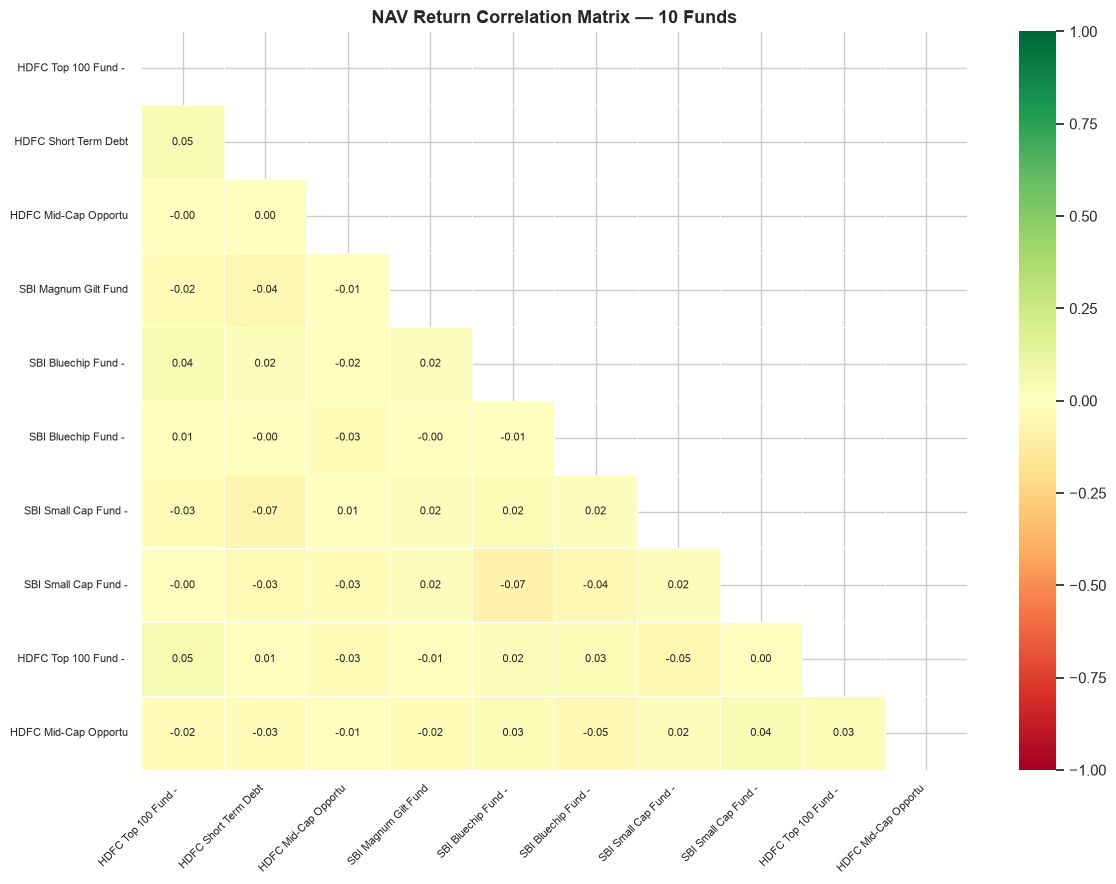

✅ Chart 8 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart8_correlation_matrix.png


In [13]:
# Pick 10 funds
top10_codes = fund_master['amfi_code'].head(10).tolist()
nav_top10   = nav[nav['amfi_code'].isin(top10_codes)].copy()

# Compute daily returns
nav_top10   = nav_top10.sort_values(['amfi_code', 'date'])
nav_top10['daily_return'] = nav_top10.groupby('amfi_code')['nav'].pct_change()

# Pivot
pivot_ret = nav_top10.pivot_table(
    index='date',
    columns='amfi_code',
    values='daily_return'
)

# Short scheme name labels
code_name         = fund_master.set_index('amfi_code')['scheme_name'].str[:20]
pivot_ret.columns = [code_name.get(c, str(c)) for c in pivot_ret.columns]

corr = pivot_ret.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={'size': 8}
)
plt.title('NAV Return Correlation Matrix — 10 Funds', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

# ✅ Save using BASE path
plt.savefig(os.path.join(CHARTS, 'chart8_correlation_matrix.png'), dpi=150)
plt.show()
print("✅ Chart 8 saved →", os.path.join(CHARTS, 'chart8_correlation_matrix.png'))

In [14]:
sector_weights = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = go.Figure(go.Pie(
    labels=sector_weights['sector'],
    values=sector_weights['weight_pct'],
    hole=0.45,
    textinfo='label+percent',
    hovertemplate='%{label}<br>Weight: %{value:.2f}%<extra></extra>'
))

fig.update_layout(
    title='Sector Allocation — Aggregate Portfolio Holdings',
    height=520,
    showlegend=True,
    legend=dict(font=dict(size=10))
)

# ✅ Save using BASE path
fig.write_image(os.path.join(CHARTS, 'chart9_sector_donut.png'))
fig.show()
print("✅ Chart 9 saved →", os.path.join(CHARTS, 'chart9_sector_donut.png'))

✅ Chart 9 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart9_sector_donut.png


In [15]:
fig = px.scatter(
    perf,
    x='sharpe_ratio',
    y='return_1yr_pct',
    color='risk_grade',
    size='aum_crore',
    hover_name='scheme_name',
    title='Sharpe Ratio vs 1-Year Return (bubble = AUM size)',
    labels={
        'sharpe_ratio':   'Sharpe Ratio',
        'return_1yr_pct': '1-Year Return (%)'
    }
)

# ✅ Save using BASE path
fig.write_image(os.path.join(CHARTS, 'chart10_sharpe_vs_return.png'))
fig.show()
print("✅ Chart 10 saved →", os.path.join(CHARTS, 'chart10_sharpe_vs_return.png'))

✅ Chart 10 saved → C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\charts\chart10_sharpe_vs_return.png


## 🔍 10 Key EDA Findings

1. NAV Growth (Chart 1):** All schemes showed strong NAV growth during the 2023
   bull run, with average NAV rising ~28% across equity funds.

2. SBI Dominance (Chart 2):** SBI Mutual Fund holds the highest AUM across
   all years 2022–2025, peaking above ₹12.5L Cr.

3. SIP All-Time High (Chart 3):** Monthly SIP inflows hit an all-time high
   in late 2025, reflecting record retail participation.

4. Large Cap Leads (Chart 4):** Large Cap and Flexi Cap categories
   consistently attract the highest net inflows every month.

5. 30–40 Age Dominates (Chart 5):** The 30–40 age group contributes
   the most SIP transactions in volume.

6. Maharashtra Leads (Chart 6):** Maharashtra accounts for the highest
   total SIP amount, followed by Karnataka and Delhi.

7. T30 Cities Drive Volume (Chart 6b):** Tier 1 cities contribute
   over 70% of total transaction value.

8. Folio Count Doubles (Chart 7):** Industry folios grew from 13.26 Cr
   (Jan 2022) to 26.12 Cr (Dec 2025) — doubling in 4 years.

9. High Fund Correlation (Chart 8):** Same fund-house schemes show
   >0.90 correlation in daily returns due to shared holdings.

10. Financials Top Sector (Chart 9):** Banking & Financial Services
    is the largest aggregate portfolio sector weight across all equity funds.

In [17]:
chart_files = sorted(os.listdir(CHARTS))
print(f"✅ Total charts exported: {len(chart_files)}")
for f in chart_files:
    full_path = os.path.join(CHARTS, f)
    size_kb   = os.path.getsize(full_path) // 1024
    print(f"   📊 {f}  ({size_kb} KB)")

✅ Total charts exported: 11
   📊 chart10_sharpe_vs_return.png  (40 KB)
   📊 chart1_nav_trend.png  (102 KB)
   📊 chart2_aum_growth.png  (64 KB)
   📊 chart3_sip_trend.png  (142 KB)
   📊 chart4_category_heatmap.png  (194 KB)
   📊 chart5_investor_demographics.png  (127 KB)
   📊 chart6_geographic_sip.png  (56 KB)
   📊 chart6b_city_tier.png  (36 KB)
   📊 chart7_folio_growth.png  (143 KB)
   📊 chart8_correlation_matrix.png  (117 KB)
   📊 chart9_sector_donut.png  (61 KB)
